In [1]:
#!/usr/bin/env python3
import os
import subprocess
import numpy as np
import math
from tools import (
    load_waveform_data,
    compute_pickoff_values_and_plot_random
)
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from scipy.interpolate import griddata
from matplotlib.path import Path
import shutil

# ---------------- USER‐DEFINED PARAMETERS ----------------
siggen_dir    = '/nas/longleaf/home/kbhimani/siggen_ccd/Analysis/siggen_activeness/icpc_siggen'
stester       = os.path.join(siggen_dir, 'stester')
config_path   = '/nas/longleaf/home/kbhimani/siggen_ccd/Analysis/siggen_activeness/icpc_siggen/config_files/ponama_1.config'
waveforms_dir = '/nas/longleaf/home/kbhimani/siggen_ccd/Analysis/siggen_activeness/waveforms/ponama_1'
r_min, r_max, dr = 0.0, 35, 0.5
z_min, z_max, dz = 0.0, 51, 0.5

# trapezoid filter params
step_time_out = 16
rise  = 10000; flat = 3000; pickoff = 13000
rise_samp    = math.floor(rise / step_time_out)
flat_samp    = math.floor(flat / step_time_out)
pickoff_samp = math.floor(pickoff / step_time_out)

# interpolation & plotting
interp_method = 'cubic'
grid_size     = 200
v_min, v_max  = 0.0, 1.0
# --------------------------------------------------------

In [2]:
os.makedirs(waveforms_dir, exist_ok=True)

# 1) WRITE A SINGLE COMMAND‐FILE
cmd_file = os.path.join(waveforms_dir, 'all_stester_cmds.txt')
with open(cmd_file, 'w') as f:
    # common setup
    f.write("cart\n")
    f.write("tau 0\n")
    f.write("dif 1\n")
    f.write("ccs 0.1\n\n")

    # one 'sig' line per (r,z)
    for r in np.arange(r_min, r_max + dr/2, dr):
        for z in np.arange(z_min, z_max + dz/2, dz):
            # build a safe filename with 'p' instead of '.'
            fname = f"wf_r{r:.2f}_z{z:.2f}".replace('.', 'p')
            out_fname = f"{fname}.spe"
            out_path  = os.path.join(waveforms_dir, out_fname)

            # write the sig command
            f.write(f"sig {r:.2f} 0.00 {z:.2f} {out_path}\n")

    # quit at end
    f.write("\nquit\n")

In [3]:
# 2) RUN FIELDGEN TO CALCULATE THE WP
! /nas/longleaf/home/kbhimani/siggen_ccd/Analysis/siggen_activeness/icpc_siggen/mjd_fieldgen /nas/longleaf/home/kbhimani/siggen_ccd/Analysis/siggen_activeness/icpc_siggen/config_files/ponama_1.config


Reading values from config file /nas/longleaf/home/kbhimani/siggen_ccd/Analysis/siggen_activeness/icpc_siggen/config_files/ponama_1.config
verbosity_level: 2
Line: xtal_length 50.5         # z length
xtal_length: 50.500000
Line: xtal_radius 34.5         # radius
xtal_radius: 34.500000
Line: top_bullet_radius    0   # bulletization radius at top of crystal
top_bullet_radius: 0.000000
Line: bottom_bullet_radius 0   # bulletization radius at bottom of BEGe crystal
bottom_bullet_radius: 0.000000
Line: pc_length    2.1         # point contact length
pc_length: 2.100000
Line: pc_radius    1.4         # point contact radius
pc_radius: 1.400000
Line: taper_length 4.5         # size of 45-degree taper at bottom of ORTEC-type crystal
bottom_taper_length: 4.500000
Line: wrap_around_radius 0     # wrap-around radius for BEGes. Set to zero for ORTEC
wrap_around_radius: 0.000000
Line: ditch_depth        0     # depth of ditch next to wrap-around for BEGes. Set to zero for ORTEC
ditch_depth: 0.00000

In [4]:
# 3) RUN STESTER ONCE WITH THAT FILE
stester_cmd = f"{stester} {config_path} < {cmd_file}"
ret = subprocess.run(stester_cmd, shell=True, check=False, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
if ret.returncode != 0:
    print("stester failed:", ret.stderr.decode())
os.remove(cmd_file)

In [5]:
import os
import struct
import numpy as np
import pandas as pd

def load_spe_waveform_data(directory):
    """
    Load all .spe waveforms from `directory` into a DataFrame.
    Expects filenames of the form 'wf_r{r}_z{z}.spe' where decimals are replaced by 'p',
    e.g. 'wf_r0p50_z1p00.spe' -> r=0.50, z=1.00.
    Skips a 36-byte header, then reads the rest as float32, drops the last sample,
    and scales by 1/1000.
    """
    records = []
    for fname in os.listdir(directory):
        if not fname.lower().endswith('.spe'):
            continue

        base = os.path.splitext(fname)[0]         # strip '.spe'
        parts = base.split('_')
        if len(parts) != 3 or not parts[1].startswith('r') or not parts[2].startswith('z'):
            # unexpected name pattern
            continue

        # convert '0p50' -> '0.50'
        try:
            r = float(parts[1][1:].replace('p', '.'))
            z = float(parts[2][1:].replace('p', '.'))
        except ValueError:
            # skip if we can't parse
            continue

        path = os.path.join(directory, fname)
        with open(path, 'rb') as f:
            f.read(36)    # skip 36-byte header
            raw = f.read()

        count = len(raw) // 4
        # unpack as float32, drop the very last sample, and scale
        wf = np.array(struct.unpack(f'{count}f', raw), dtype=float)[:-1] / 1000.0

        records.append({
            'r': r,
            'z': z,
            'wf': wf
        })

    return pd.DataFrame(records)

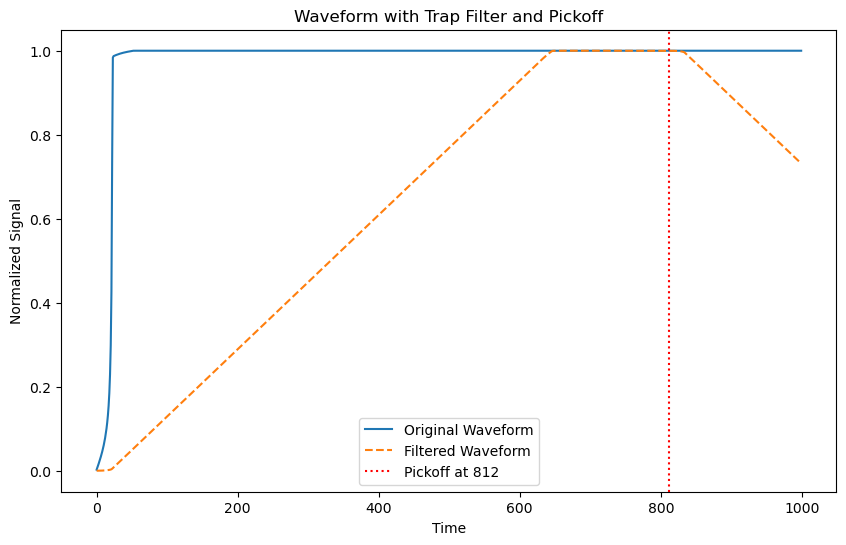

In [6]:
# 4) LOAD & PROCESS
waveforms_df = load_spe_waveform_data(waveforms_dir)
compute_pickoff_values_and_plot_random(
    waveforms_df,
    rise    = rise_samp,
    flat    = flat_samp,
    pickoff = pickoff_samp,
    plot_random = True
)
# shutil.rmtree(waveforms_dir)


In [7]:
waveforms_df.head()

,r,z,wf,energy_estimate
0,35.0,51.0,"[0.0008581874370574951, 0.0025076940059661867,...",0.999998
1,0.0,2.5,"[0.3701883239746094, 0.6466578369140625, 0.745...",0.999360
2,0.0,3.0,"[0.3938758850097656, 0.6794620971679688, 0.760...",0.999321
3,0.0,3.5,"[0.35286639404296877, 0.70596826171875, 0.7740...",0.999390
4,0.0,4.0,"[0.2718708190917969, 0.71671240234375, 0.78586...",0.999526


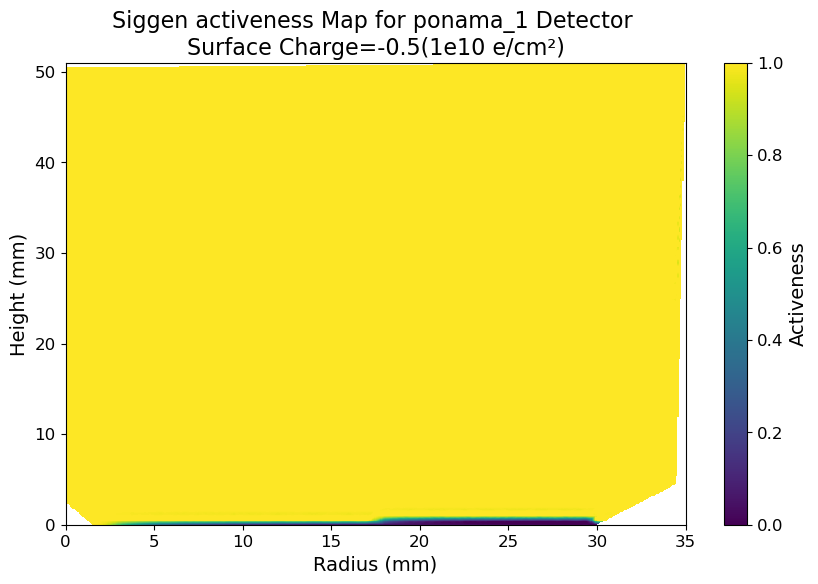

In [8]:
# 5) INTERPOLATE
int_method= 'cubic'
filter_sc = '-0.5'
filter_det = 'ponama_1'
# Color-scale bounds for linear scale
v_min_lin = 0.0
v_max_lin = 1.00

# 4) Extract r, z, and energy from the filtered DataFrame
r_plot = waveforms_df['r'].to_numpy()
z_plot = waveforms_df['z'].to_numpy()
energy_estimate = waveforms_df['energy_estimate'].to_numpy()

# 5) Prepare interpolation grid
grid_size = 500
r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
r_grid, z_grid = np.meshgrid(r_lin, z_lin)

# 6) Interpolate the data if enough points exist
if len(r_plot) <= 2:
    print("Not enough points for interpolation. Exiting.")
    exit(1)

energy_interp = griddata(
    (r_plot, z_plot),
    energy_estimate,
    (r_grid, z_grid),
    method=int_method
)

# 7) Clip the interpolation results to [0,1]
energy_interp_adjusted = energy_interp[:-1, :-1]
energy_interp_clipped  = np.clip(energy_interp_adjusted, 0, 1)
norm_obj   = colors.Normalize(vmin=v_min_lin, vmax=v_max_lin)
cbar_label = "Activeness"

# 9) Plot the data (using clipped values directly)
plt.figure(figsize=(10, 6))

heatmap = plt.pcolormesh(
    r_grid[:-1, :-1],
    z_grid[:-1, :-1],
    energy_interp_clipped,
    cmap=cm.viridis,
    norm=norm_obj,
    shading='auto'
)

cbar = plt.colorbar(heatmap)
cbar.set_label(cbar_label, fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Height (mm)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylim([z_plot.min(), z_plot.max()])
plt.xlim([r_plot.min(), r_plot.max()])
plt.title(f'Siggen activeness Map for {filter_det} Detector \nSurface Charge={filter_sc}(1e10 e/cm²)', fontsize=16)

# 10) Build output filename
fname_out = f"figs/activeness_map_siggen_{int_method}_sc={filter_sc}_{filter_det}_linear_full.png"

# 11) Save and display
plt.savefig(fname_out, dpi=100)
plt.show()


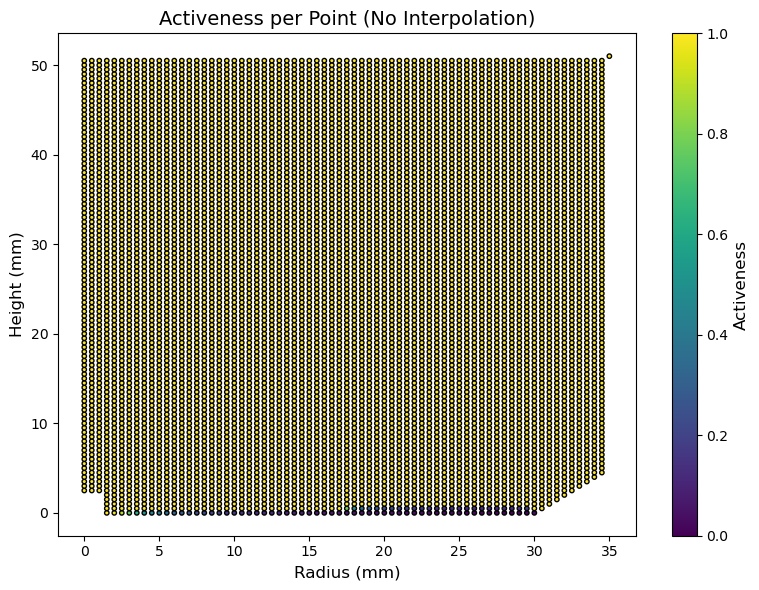

In [9]:
import matplotlib.pyplot as plt
from matplotlib import cm, colors

# Assuming you’ve already got these from your DataFrame:
r = waveforms_df['r'].to_numpy()
z = waveforms_df['z'].to_numpy()
act = waveforms_df['energy_estimate'].to_numpy()

# Color normalization (same bounds as before)
norm = colors.Normalize(vmin=v_min_lin, vmax=v_max_lin)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    r, z,
    c=act,
    cmap=cm.viridis,
    norm=norm,
    s=10,           # point size; feel free to adjust
    edgecolors='k'  # little black border for clarity
)
cbar = plt.colorbar(sc)
cbar.set_label('Activeness', fontsize=12)

plt.xlabel('Radius (mm)', fontsize=12)
plt.ylabel('Height (mm)', fontsize=12)
plt.title('Activeness per Point (No Interpolation)', fontsize=14)
plt.tight_layout()
plt.show()
